# Start model Structured Product Assignment B1
*Course year 2025-2026*

This notebook provides a starting model to Structured Products Assignment B2. You can fill in blank parts with your own code; also feel free to adjust or replace existing parts. For details on the assignment, please check Canvas. Ensure that the Notebook reads as a cohesive and self-contained report. Take into account factors such as style hints, redundant and inefficient code, proper documentation and consistency of the code.

**Group 1**<br>
**Rick Hezeman (s3450902)**<br>
**Roy Mulder (s2587572)**<br>
**Jeroen Pouwels (s2389878)**<br>
**Ruben Stevenaar (s2633582)**<br>
**Justus Straus (s2636662)**<br>

<p align="center">
<img src="https://blog.billyoh.com/wp-content/uploads/2021/08/cool-hedge-ideas-2-outdoor-hedge-maze-1.jpg" width="100px" alt="Hedge">
</p>

Useful links:<br>
[Introduction to Jupyter Notebook](https://www.dataquest.io/blog/jupyter-notebook-tutorial/)<br>
[UT JupyterLab wiki](https://jupyter.wiki.utwente.nl/)<br>
[Markdown language](https://learn.microsoft.com/en-us/azure/devops/project/wiki/markdown-guidance?view=azure-devops)<br>

In [57]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from math import exp, log
from scipy.stats import norm

In [58]:
np.random.seed(34)

In [ ]:
"""Dynamically delta hedge portfolio of short call options"""
S = 100  # Initial stock price
v = 0.01  # Volatility (0.01=1%)
r = 0.0276  # Risk-free rate (10-year German bond yield)
K = 100  # Strike price, ATM option
T = 1  # Expiration date, in years
N = 252 # Number of trading days in a year         
dt = T / N # Time increment per trading day
sigma = 0.20 # Annualized volatility (20%)
n_calls = 1  # Number of call options in the portfolio

In [60]:
def plot_results(t, array_t, array_delta, array_price, array_strike, array_position, array_nr_stocks):
    """Plot (i) portfolio delta, (ii) stock price, (iii) #stocks traded and
       (iv) stock position over time"""

    # Convert arrays
    array_t_plot = array_t[0:t]
    array_delta_plot = array_delta[0:t]
    array_price_plot = array_price[0:t]
    array_strike_plot = array_strike[0:t]
    array_position_plot = array_position[0:t]
    array_nr_stocks_plot = array_nr_stocks[0:t]

    fig, axes = plt.subplots(nrows=2, ncols=2)
    fig.tight_layout(h_pad=1)

    # Define plots
    delta_plot, = axes[0, 0].plot(array_t_plot, array_delta_plot)
    price_plot, = axes[0, 1].plot(array_t_plot, array_price_plot)
    strike_plot, = axes[0, 1].plot(array_t_plot, array_strike_plot)
    stocks_plot, = axes[1, 0].plot(array_t_plot, array_nr_stocks_plot)
    position_plot, = axes[1, 1].plot(array_t_plot, array_position_plot)

    # Define axis labels
    axes[0, 0].set(xlabel="Day", ylabel="Delta")
    axes[0, 1].set(xlabel="Day", ylabel="Stock price")
    axes[1, 0].set(xlabel="Day", ylabel="# stocks traded")
    axes[1, 1].set(xlabel="Day", ylabel="Long position")

    # Set axis ranges
    axes[0, 0].set_ylim([-1, 1])
    axes[1, 1].set_ylim([-0.1, 1.1 * n_calls])
    axes[1, 0].set_ylim([-0.1, 2*n_calls])  # If needed, adjust this range

    # Define legends
    axes[0, 1].legend([price_plot, strike_plot], ["Stock", "Strike"])

    plt.show()

In [61]:
def bs_price_call(S, K, r, sigma, tau):
    "BS price of a European call option"
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)


def bs_delta_call(S, K, r, sigma, tau):
    "BS delta of a European call option"
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    return float(norm.cdf(d1))

z = np.random.normal(0.0, 1.0, size=N)

def GBM(S: float, r: float, sigma: float, dt: float, z: np.ndarray) -> np.ndarray:
    "Simulate Geometric Brownian Motion (GBM) stock price paths."
    price_change = np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)

    Stock_price = np.zeros(N+1)
    Stock_price[0] = S
    for t in range(1, N + 1):
        Stock_price[t] = Stock_price[t - 1] * price_change[t - 1]
    # Return the simulated stock price path
    print(S)
    return Stock_price


In [64]:
# Initialize output variables and arrays
array_t = np.zeros(N+1)
array_delta = np.zeros(N+1)
array_price = np.zeros(N+1)
array_strike = np.zeros(N+1)
array_position = np.zeros(N+1)
array_nr_stocks = np.zeros(N+1)
array_portfolio_value = np.zeros(N+1)

# Compute initial properties of call options
# Hint: write a function that returns price and delta of the option
option0 = bs_price_call(S, K, r, sigma, T)
option_costs = option0 * n_calls
delta_initial = bs_delta_call(S, K, r, sigma, T)


# Hint: use Black-Scholes formula for the option price
array_price = GBM(S, r, sigma, dt, z)



position_long = 0  # Initial long stock position
portfolio_value = 0  
total_interest = 0  # Initialize total interest payments

# Compute initial hedge, initialization

position_long += delta_initial * n_calls  # Update long stock position based on stocks bought/sold
long_value = position_long * array_price[0]  # Value of long stock position
portfolio_value += long_value - (option0 * n_calls)    # Update value based on stocks bought/sold
portfolio_delta = position_long - (delta_initial * n_calls)  # Update portfolio delta
adjust_hedge = abs(position_long) # Update hedge


# Hint: portfolio delta should be 0 after this initial hedge

# Print initial output
print('\n======= Initial =======')
print('Stock price %.2f' % S)
print('Option value %.2f' % option0) 
print('Long position %.2f' % position_long)
print('Total transactions %.2f' % abs(adjust_hedge))  # Nr. of transactions
print('long_value: %.2f' % long_value)
print('Portfolio value %.2f' % portfolio_value)
print('Delta %.2f' % portfolio_delta)

# Store data at t=0
array_t[0] = 0
array_delta[0] = portfolio_delta
array_strike[:] = K
array_position[0] = position_long  # Store stock positions
array_nr_stocks[0] = abs(adjust_hedge)  # Store nr. of transactions
array_portfolio_value[0] = portfolio_value  # Store portfolio value


# Simulate portfolio updates for time horizon
for t in range(1, N+1):
    tau = N - t

    array_t[t] = t
    delta_option = bs_delta_call(array_price[t], K, r, sigma, tau)  # Compute new delta of the option
    rebalance = delta_option * n_calls - array_position[t-1]  # Determine how much to rebalance
    array_position[t] = array_position[t-1] + rebalance # Update stock positions

    array_delta[t] = array_position[t] - (delta_option * n_calls) # Update portfolio delta
    

    long_value = array_position[t] * array_price[t]  # Value of long stock position
    option_value = bs_price_call(array_price[t], K, r, sigma, tau) * n_calls  # Value of option position
    array_portfolio_value[t] = long_value - option_value # Store cost balance

    adjust_hedge = abs(rebalance)  # Update hedge adjustment
    array_nr_stocks[t] = array_nr_stocks[t-1] + adjust_hedge  # Store number of stocks traded

    position_long = array_position[t-1]  # Update long position for printing

    assert array_delta[t] == 0, "Oh no! You did not listen well enough to Wouter and your portfolio is not delta neutral anymore. Please check your code and try again."

      # Initial cost of the option position
    # code interest payments, this means that cash balance would be below zero
    if array_position[t-1]*array_price[t-1] - option_costs > 0:
        interest_payment = (array_position[t-1]*array_price[t-1] - option_costs) * r * dt
        array_portfolio_value[t] -= interest_payment  # Subtract interest payment from portfolio value
        total_interest += interest_payment  # Accumulate total interest payments


    

    

    print('\n=======', t, '=======')
        # If maturity, close all option and stock positions here
    if t == (N):
        option_value = max(array_price[t] - K, 0) * n_calls
        array_portfolio_value[t] = long_value - option_value - interest_payment # Final portfolio value, overwrite for corect option value at maturity
        print('At maturity, portfolio value is %.2f' % array_portfolio_value[t])
        array_position[t]= 0  # Close stock position
        # Close stock position
        #    Determine final portfolio value (hint: should be close to 0)



    # Print console output
    
    print('Stock price %.2f' % array_price[t])
    print('Option value %.2f' % option_value)
    print('Hedge adjustment %.2f' % adjust_hedge)
    print('Option delta %.2f' % delta_option)
    print('Long position %.2f' % array_position[t])
    print('Total transactions %.2f' % array_nr_stocks[t])
    print('Portfolio value %.2f' % array_portfolio_value[t])
    print('Delta %.2f' % array_delta[t])
    print('Interest payment %.4f' % interest_payment)
    print('Total interest payments %.4f' % total_interest)



100

======= Initial =======
Stock price 100.00
Option value 9.29
Long position 0.59
Total transactions 0.59
long_value: 59.41
Portfolio value 50.11
Delta 0.00

======= 1 =======
Stock price 100.31
Option value 100.23
Hedge adjustment 0.41
Option delta 1.00
Long position 1.00
Total transactions 1.00
Portfolio value 0.07
Delta 0.00
Interest payment 0.0055
Total interest payments 0.0055

======= 2 =======
Stock price 99.37
Option value 99.29
Hedge adjustment 0.00
Option delta 1.00
Long position 1.00
Total transactions 1.00
Portfolio value 0.06
Delta 0.00
Interest payment 0.0100
Total interest payments 0.0155

======= 3 =======
Stock price 97.44
Option value 97.36
Hedge adjustment 0.00
Option delta 1.00
Long position 1.00
Total transactions 1.00
Portfolio value 0.07
Delta 0.00
Interest payment 0.0099
Total interest payments 0.0253

======= 4 =======
Stock price 96.88
Option value 96.79
Hedge adjustment 0.00
Option delta 1.00
Long position 1.00
Total transactions 1.00
Portfolio value 0.07


C:\Users\justu\AppData\Local\Temp\ipykernel_33952\3088904028.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
C:\Users\justu\AppData\Local\Temp\ipykernel_33952\3088904028.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


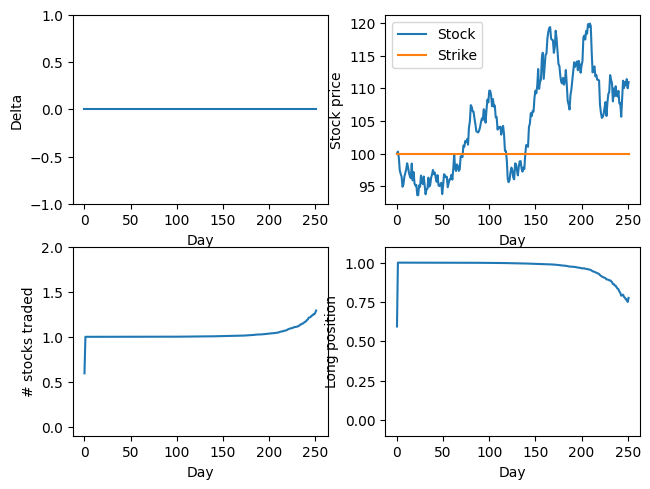

In [63]:
# Update price plot
plot_results(N, array_t, array_delta, array_price, array_strike, array_position, array_nr_stocks)